# Computational Statistics & Data Analysis - Exercise Sheet 7

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import math
import time
import datetime

## Task 1

$y=X\beta+\epsilon$ with $\epsilon \sim N(0,\sigma^2I)$

Likelihood function:    $L(\beta,\sigma^2)=exp(-(y-X\beta)^T(y-X\beta)/(2\sigma^2))/(2\pi \sigma^2)^{n/2}$

loglikelihood function: $ln L(\beta,\sigma^2) = -n/2  ln(2\pi \sigma^2)-1/(2\sigma^2)(y-X\beta)^T(y-X\beta)$

maximize:               $-n/(2\sigma^2)+1/(2\sigma^4)(y-X\beta)^T(y-X\beta)$

$\hat \sigma^2 = 1/n (y-X\beta)^T(y-X\beta)$
                        
now plug in for $\beta$ $\hat \beta = (X^TX)^{-1}X^Ty$

$\hat \sigma^2 = 1/n (y-X(X^TX)^{-1}X^Ty)^T(y-X(X^TX)^{-1}X^Ty)$

## Task 2

In [3]:
df = pd.read_excel("ex7task2.xlsx")
df

,DLPFC,task1,task2,task3
0,-0.840873,0,0,0
1,-1.970057,0,0,0
2,-2.881915,0,0,0
3,-3.143601,0,0,0
4,-2.747359,0,0,0
...,...,...,...,...
355,0.522643,0,0,1
356,0.464077,0,0,0
357,-0.013436,0,0,0
358,-0.367076,0,0,0


### t-tests for all tasks seperately

H0: $\mu_0=\mu_1$

H1: $\mu_0\neq\mu_1$

In [6]:
x1_task1=df[df["task1"] == 1]["DLPFC"].to_numpy()
x0_task1=df[df["task1"] == 0]["DLPFC"].to_numpy()

x1_task2=df[df["task2"] == 1]["DLPFC"].to_numpy()
x0_task2=df[df["task2"] == 0]["DLPFC"].to_numpy()

x1_task3=df[df["task3"] == 1]["DLPFC"].to_numpy()
x0_task3=df[df["task3"] == 0]["DLPFC"].to_numpy()

In [16]:
x1=x1_task1
x0=x0_task1

mean_1=x1.mean()
mean_0=x0.mean()

N1 = len(x1)
N0 = len(x0)

s_x1 = x1.std(ddof=1)
s_x0 = x0.std(ddof=1)

sigma=np.sqrt(((N1-1)*s_x1**2+(N0-1)*s_x0**2)*(1/N1+1/N0)/(N1+N0-2))

t1=(mean_1-mean_0)/sigma

p1 = 2 * (1 - sp.stats.t.cdf(abs(t1), N1 + N0 - 2))

t1,p1

(1.8389949404315655, 0.0667439706525581)

In [17]:
x1=x1_task2
x0=x0_task2

mean_1=x1.mean()
mean_0=x0.mean()

N1 = len(x1)
N0 = len(x0)

s_x1 = x1.std(ddof=1)
s_x0 = x0.std(ddof=1)

sigma=np.sqrt(((N1-1)*s_x1**2+(N0-1)*s_x0**2)*(1/N1+1/N0)/(N1+N0-2))

t2=(mean_1-mean_0)/sigma

p2 = 2 * (1 - sp.stats.t.cdf(abs(t2), N1 + N0 - 2))

t2,p2

(1.1274222348034264, 0.2603190626396892)

In [18]:
x1=x1_task3
x0=x0_task3

mean_1=x1.mean()
mean_0=x0.mean()

N1 = len(x1)
N0 = len(x0)

s_x1 = x1.std(ddof=1)
s_x0 = x0.std(ddof=1)

sigma=np.sqrt(((N1-1)*s_x1**2+(N0-1)*s_x0**2)*(1/N1+1/N0)/(N1+N0-2))

t3=(mean_1-mean_0)/sigma

p3 = 2 * (1 - sp.stats.t.cdf(abs(t3), N1 + N0 - 2))

t3,p3

(1.2946335694002726, 0.1962810526965746)

### F-test:

H0: $\beta_1 = \beta_2 = \beta_3 = 0$

H1: There is one $\beta_i \neq 0$

We want to compare reduced Model: $y = \beta_0$ with the full model $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3$

In [24]:
# full model
y=df["DLPFC"].to_numpy()
X = df[["task1", "task2", "task3"]].to_numpy()

X_full = np.column_stack((np.ones(len(y)), X))

beta_full = np.linalg.inv(X_full.T @ X_full) @ (X_full.T @ y)
y_hat_full = X_full @ beta_full

RSS_full = np.sum((y - y_hat_full)**2)

In [25]:
#reduced model
y_mean = np.mean(y)
y_hat_restricted = np.ones(len(y)) * y_mean

RSS_restricted = np.sum((y - y_hat_restricted)**2)

In [26]:
# F-value
n = len(y)
q = 3
p = 4

F = ((RSS_restricted - RSS_full) / q) / (RSS_full / (n - p))
F

3.752583889011789

In [28]:
# p-value
df1 = q
df2 = n - p

p_value = 1 - sp.stats.f.cdf(F, df1, df2)

p_value

0.011202807119676583

### Is it i.i.d.?

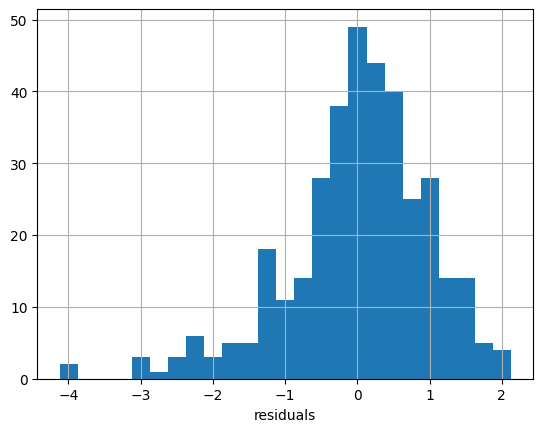

In [35]:
# histogram of residuals
plt.hist(y - y_hat_full, bins=25)

plt.xlabel("residuals")
plt.grid()
plt.show()

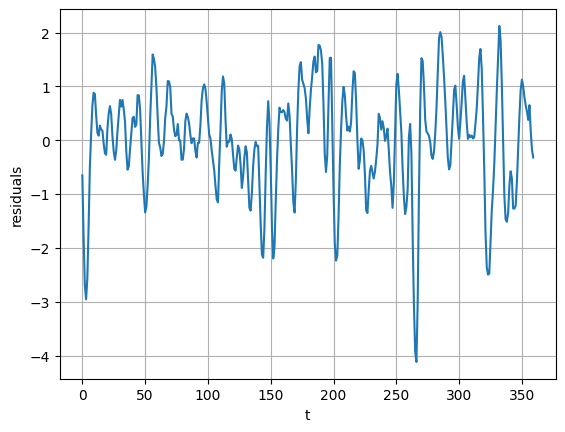

In [38]:
plt.plot(y - y_hat_full)

plt.xlabel("t")
plt.ylabel("residuals")

plt.grid()
plt.show()

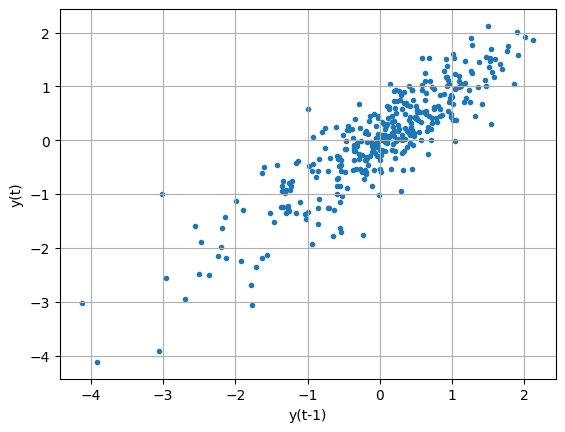

In [43]:
plt.scatter((y - y_hat_full)[:-1],(y - y_hat_full)[1:],marker=".")

plt.xlabel("y(t-1)")
plt.ylabel("y(t)")

plt.grid()
plt.show()

It seems like the data isn't i.i.d. because the plot above shows a positive correlation between following measurements! 
Looking at the histogram, they might still be identically distributed, because it kinda looks like a normal distribution. But it is definitely not independent!

### confidence intervals
$Var(\beta) = \hat \sigma^2 (X^TX)^{-1}$

and $\hat \sigma^2 = (y-X\hat \beta)^T(y-X\hat \beta)/(n-p)$

In [47]:
# sigma^2
sigmasqrd = RSS_full/(n-p)
Var_beta = sigmasqrd* sp.linalg.inv(X_full.T@X_full)

In [48]:
def confidence_interval(Var_beta,alpha):
    t_crit=sp.stats.t.ppf(alpha,n-p)
    
    c = np.sqrt(np.diag(Var_beta))*t_crit
    return c

In [51]:
confidence_interval(Var_beta,0.01)

array([-0.17986802, -0.33834612, -0.33834612, -0.33834612])

In [55]:
alpha = [0.1,0.05,0.01]

for a in alpha:
    c=abs(confidence_interval(Var_beta,a))
    lower = beta_full - c
    upper = beta_full + c
    print(fr"""
    $\alpha =${a}:
    _____________________
    $\beta_0 \in$ [{lower[0].round(4)},{upper[0].round(4)}]
    $\beta_1 \in$ [{lower[1].round(4)},{upper[1].round(4)}]
    $\beta_2 \in$ [{lower[2].round(4)},{upper[2].round(4)}]
    $\beta_3 \in$ [{lower[3].round(4)},{upper[3].round(4)}]
    
    
    """)


    $\alpha =$0.1:
    _____________________
    $\beta_0 \in$ [-0.287,-0.0893]
    $\beta_1 \in$ [0.208,0.5798]
    $\beta_2 \in$ [0.1288,0.5006]
    $\beta_3 \in$ [0.1475,0.5193]
    
    
    

    $\alpha =$0.05:
    _____________________
    $\beta_0 \in$ [-0.3151,-0.0612]
    $\beta_1 \in$ [0.1552,0.6327]
    $\beta_2 \in$ [0.0759,0.5534]
    $\beta_3 \in$ [0.0946,0.5721]
    
    
    

    $\alpha =$0.01:
    _____________________
    $\beta_0 \in$ [-0.368,-0.0083]
    $\beta_1 \in$ [0.0556,0.7323]
    $\beta_2 \in$ [-0.0237,0.653]
    $\beta_3 \in$ [-0.005,0.6717]
    
    
    


## Task 3

In [78]:
XA =np.array([2,1,4,3,2,1,3,2,4,3])
XB =np.array([4,5,4,6,5,7,4,5,6,4])
X0=np.array([2,1,4,3,2,1,3,2,4,3,4,5,4,6,5,7,4,5,6,4])

lambdaA = np.sum(XA)/len(XA)
lambdaB = np.sum(XB)/len(XB)
lambda0 = (np.sum(XA)+np.sum(XB))/(len(XA)+len(XB))

lambdaA,lambdaB,lambda0

(2.5, 5.0, 3.75)

In [79]:
def loglikelihood(x,lamb):
    return np.sum(x*np.log(lamb)-np.log(x))-len(x)*lamb

In [80]:
loglikelihood(XA,lambdaA)+loglikelihood(XB,lambdaB) , loglikelihood(X0,lambda0)

(4.328376519341656, 0.08090059945671157)

In [82]:
loglikelihood(X0,lambda0)-(loglikelihood(XA,lambdaA)+loglikelihood(XB,lambdaB))

-4.247475919884945

In [83]:
np.exp(loglikelihood(X0,lambda0)-(loglikelihood(XA,lambdaA)+loglikelihood(XB,lambdaB)))

0.014300283454997318

In [84]:
-2*(loglikelihood(X0,lambda0)-(loglikelihood(XA,lambdaA)+loglikelihood(XB,lambdaB)))

8.49495183976989

In [86]:
D = 8.485
k = 1

p_value = sp.stats.chi2.sf(D, df=k)
print(p_value)

0.003580865794245657
